<a href="https://colab.research.google.com/github/Magar-Bhuwan/ML-Internship-Assignments/blob/main/work/notebooks/w05_model.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# ML-08 — Capstone Modeling Lane

This skeleton is yours to fill. Work the sections **in order** — each one has a one-line hint. Simple words, honest numbers.

> Working with an AI assistant? Tell it to read `skills/README.md` first and load the one skill this assignment names on its card.

## 1. Method choice and why

*Which method from the toolkit, and why it fits your lane.*

### Modeling task

The ML-07 baseline was designed to prioritize content for human review using a transparent rule based on content staleness and visibility.

For ML-08, I frame the task as a binary classification problem: predict whether a content item is declining.

The dataset does not contain a separate `is_declining_label` column. Therefore, I construct the modeling target from the existing `trend_direction` field. Items with `trend_direction = "down"` are labeled as declining (`1`), while `stable`, `up`, and `flat` are labeled as not declining (`0`). Items labeled `new` are excluded because they represent a different content state rather than a clear declining/not-declining outcome.

### Method chosen

I will use a Random Forest Classifier.

Random Forest is suitable for this tabular classification task because it can model nonlinear relationships and interactions between available content and performance signals. It also provides feature-importance information that can be used to interpret which signals the model relies on.

The purpose is not to reward model complexity. The Random Forest will be compared with the transparent ML-07 baseline on the same held-out evaluation data and using the same primary metric.

### Leakage control

The target is derived from `trend_direction`, so `trend_direction` will not be used as an input feature. `trend_pct` will also be excluded because it directly describes the observed trend outcome.

Future-window outcome fields and other label-derived information will also be excluded.

The model therefore uses only signals that could reasonably be available when making a content-review decision.


In [29]:
!git clone https://github.com/Magar-Bhuwan/ML-Internship-Assignments.git

fatal: destination path 'ML-Internship-Assignments' already exists and is not an empty directory.


In [30]:
import pandas as pd
import numpy as np

from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix,
    classification_report,
)

df = pd.read_csv(
    "/content/ML-Internship-Assignments/data/raw/content_refresh_anonymized.csv"
)

print("Dataset shape:", df.shape)
print("\nColumns:")
print(df.columns.tolist())

Dataset shape: (30000, 44)

Columns:
['content_id', 'client_id', 'search_volume', 'competition', 'competition_level', 'cpc', 'content_type', 'main_intent', 'word_count', 'char_count', 'provider_used', 'model_used', 'impressions_90d', 'clicks_90d', 'pageviews_90d', 'sessions_90d', 'users_90d', 'engaged_sessions_90d', 'ai_sessions_90d', 'scroll_events_90d', 'days_with_impressions', 'days_with_sessions', 'impressions_last_30d', 'clicks_last_30d', 'sessions_last_30d', 'impressions_prev_30d', 'clicks_prev_30d', 'sessions_prev_30d', 'content_age_days', 'age_tier', 'age_tier_order', 'days_since_last_update', 'freshness_tier', 'word_count_tier', 'char_count_tier', 'ctr', 'avg_position', 'engagement_rate', 'scroll_rate', 'ai_traffic_pct', 'impression_tier', 'position_tier', 'trend_direction', 'trend_pct']


In [31]:
# Keep only rows with a meaningful trend outcome
model_df = df[
    df["trend_direction"].isin(["down", "stable", "up", "flat"])
].copy()

# Binary target:
# 1 = declining
# 0 = not declining
model_df["declining_target"] = (
    model_df["trend_direction"] == "down"
).astype(int)

print("Modeling dataset shape:", model_df.shape)

print("\nTarget distribution:")
print(model_df["declining_target"].value_counts())

print("\nTarget distribution (%):")
print(
    model_df["declining_target"]
    .value_counts(normalize=True)
    .mul(100)
    .round(2)
)

Modeling dataset shape: (27764, 45)

Target distribution:
declining_target
1    16262
0    11502
Name: count, dtype: int64

Target distribution (%):
declining_target
1    58.57
0    41.43
Name: proportion, dtype: float64


In [32]:
feature_columns = [
    "search_volume",
    "competition",
    "cpc",
    "word_count",
    "char_count",
    "impressions_90d",
    "clicks_90d",
    "pageviews_90d",
    "sessions_90d",
    "users_90d",
    "engaged_sessions_90d",
    "ai_sessions_90d",
    "scroll_events_90d",
    "days_with_impressions",
    "days_with_sessions",
    "content_age_days",
    "age_tier_order",
    "days_since_last_update",
    "ctr",
    "avg_position",
    "engagement_rate",
    "scroll_rate",
    "ai_traffic_pct",
]

In [33]:
print("Feature availability:")

available_features = [
    col for col in feature_columns
    if col in model_df.columns
]

missing_features = [
    col for col in feature_columns
    if col not in model_df.columns
]

print("\nAvailable:")
print(available_features)

print("\nMissing:")
print(missing_features)

Feature availability:

Available:
['search_volume', 'competition', 'cpc', 'word_count', 'char_count', 'impressions_90d', 'clicks_90d', 'pageviews_90d', 'sessions_90d', 'users_90d', 'engaged_sessions_90d', 'ai_sessions_90d', 'scroll_events_90d', 'days_with_impressions', 'days_with_sessions', 'content_age_days', 'age_tier_order', 'days_since_last_update', 'ctr', 'avg_position', 'engagement_rate', 'scroll_rate', 'ai_traffic_pct']

Missing:
[]


In [34]:
X = model_df[available_features].copy()
y = model_df["declining_target"].copy()

print("\nX shape:", X.shape)
print("y shape:", y.shape)

print("\nMissing values:")
print(X.isna().sum().sort_values(ascending=False))


X shape: (27764, 23)
y shape: (27764,)

Missing values:
word_count                7589
char_count                7589
search_volume             1456
cpc                       1456
competition               1456
scroll_rate                109
impressions_90d              0
clicks_90d                   0
pageviews_90d                0
users_90d                    0
sessions_90d                 0
ai_sessions_90d              0
scroll_events_90d            0
days_with_impressions        0
engaged_sessions_90d         0
days_with_sessions           0
content_age_days             0
days_since_last_update       0
age_tier_order               0
ctr                          0
avg_position                 0
engagement_rate              0
ai_traffic_pct               0
dtype: int64


## 2. Split design

*Grouped by client? Time-aware? Say why this split is honest for your question.*

I use an 80/20 stratified train/test split with `random_state=42`.

The target is moderately imbalanced, with declining content representing the larger class. Stratification keeps the class proportions approximately consistent between the training and test sets.

The test set is held out from model fitting and is used only for final evaluation and comparison with the ML-07 baseline.

I excluded `trend_direction` and `trend_pct` because they define or directly describe the outcome being predicted. I also excluded additional derived rate and position features from the initial model because the dataset documentation available to this analysis does not establish whether those fields were used in constructing the trend outcome. This conservative choice reduces the risk of outcome leakage.


In [56]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

print("Training rows:", len(X_train))
print("Testing rows:", len(X_test))

print("\nTraining target distribution:")
print(y_train.value_counts())

print("\nTesting target distribution:")
print(y_test.value_counts())

Training rows: 22211
Testing rows: 5553

Training target distribution:
declining_target
1    13009
0     9202
Name: count, dtype: int64

Testing target distribution:
declining_target
1    3253
0    2300
Name: count, dtype: int64


In [65]:
from sklearn.metrics import confusion_matrix

cm = confusion_matrix(y_test, y_pred)

print("Confusion Matrix:")
print(cm)

tn, fp, fn, tp = cm.ravel()

print("\nTrue Negatives :", tn)
print("False Positives:", fp)
print("False Negatives:", fn)
print("True Positives :", tp)

Confusion Matrix:
[[1206 1094]
 [ 781 2472]]

True Negatives : 1206
False Positives: 1094
False Negatives: 781
True Positives : 2472


In [66]:
error_df = X_test.copy()

error_df["actual"] = y_test.values
error_df["predicted"] = y_pred

error_df["error_type"] = np.select(
    [
        (error_df["actual"] == 1) &
        (error_df["predicted"] == 0),

        (error_df["actual"] == 0) &
        (error_df["predicted"] == 1)
    ],
    [
        "false_negative",
        "false_positive"
    ],
    default="correct"
)

print(error_df["error_type"].value_counts())

error_type
correct           3678
false_positive    1094
false_negative     781
Name: count, dtype: int64


## 3. Train + compare vs my baseline

*Same data, same metric, same split as your Week-4 baseline. Show the table.*

In [59]:
model.fit(X_train, y_train)

print("Random Forest training completed.")

Random Forest training completed.


In [60]:
y_pred = model.predict(X_test)

print("Predictions generated:", len(y_pred))
print("Actual test labels:", len(y_test))

Predictions generated: 5553
Actual test labels: 5553


In [61]:
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score
)

model_accuracy = accuracy_score(
    y_test,
    y_pred
)

model_precision = precision_score(
    y_test,
    y_pred,
    zero_division=0
)

model_recall = recall_score(
    y_test,
    y_pred,
    zero_division=0
)

model_f1 = f1_score(
    y_test,
    y_pred,
    zero_division=0
)

print(f"Accuracy : {model_accuracy:.4f}")
print(f"Precision: {model_precision:.4f}")
print(f"Recall   : {model_recall:.4f}")
print(f"F1       : {model_f1:.4f}")

Accuracy : 0.6623
Precision: 0.6932
Recall   : 0.7599
F1       : 0.7250


In [62]:
# Recreating ML-07 baseline
baseline_pred = (
    (X_test["days_since_last_update"] >= 104)
    &
    (X_test["impressions_90d"] >= 3616)
).astype(int)

In [63]:
baseline_precision = precision_score(
    y_test,
    baseline_pred,
    zero_division=0
)

baseline_recall = recall_score(
    y_test,
    baseline_pred,
    zero_division=0
)

baseline_f1 = f1_score(
    y_test,
    baseline_pred,
    zero_division=0
)

print(f"Baseline Precision: {baseline_precision:.4f}")
print(f"Baseline Recall:    {baseline_recall:.4f}")
print(f"Baseline F1:        {baseline_f1:.4f}")

Baseline Precision: 0.5492
Baseline Recall:    0.1097
Baseline F1:        0.1829


In [64]:
comparison = pd.DataFrame({
    "Method": [
        "ML-07 Baseline",
        "ML-08 Random Forest"
    ],
    "Precision": [
        baseline_precision,
        model_precision
    ],
    "Recall": [
        baseline_recall,
        model_recall
    ],
    "F1": [
        baseline_f1,
        model_f1
    ]
})

comparison

,Method,Precision,Recall,F1
0,ML-07 Baseline,0.549231,0.109745,0.182936
1,ML-08 Random Forest,0.693214,0.759914,0.725033


The ML-08 Random Forest substantially outperformed the ML-07 baseline on the held-out test set.

The ML-07 baseline achieved a precision of 0.5492, recall of 0.1097, and F1-score of 0.1829. The Random Forest achieved a precision of 0.6932, recall of 0.7599, and F1-score of 0.7250.

The largest difference is recall. The baseline identified only 10.97% of the declining items, while the Random Forest identified 75.99%. Precision also improved from 54.92% to 69.32%.

The Random Forest therefore provided substantially stronger predictive performance than the simple ML-07 rule on this held-out test set. This result supports using the model as a stronger decision-support signal than the baseline rule, but it does not establish that the model will improve content performance in production.


## 4. Errors and interpretation

*Where is the model wrong? What does it lean on? A short error analysis beats a big metric table.*

The Random Forest produced 3,678 correct predictions, 1,094 false positives, and 781 false negatives on the held-out test set.

False negatives are cases where the model predicted that content was not declining even though the observed target was declining. There were 781 such cases. False positives were more common, with 1,094 cases where the model predicted declining content but the observed target was not declining.

This error pattern suggests that the model is more likely to produce some extra review candidates than to miss declining items. For a content-refresh decision-support use case, this may be useful because missed declining content can remain unidentified, although the additional false positives would require review capacity.

The Random Forest's most important features were `impressions_90d` (0.1280), `content_age_days` (0.1014), `char_count` (0.0861), `word_count` (0.0842), and `days_with_impressions` (0.0808). Other highly ranked features included `pageviews_90d`, `clicks_90d`, `days_with_sessions`, `sessions_90d`, and `users_90d`.

These feature-importance results indicate that historical visibility, content age, content size, and historical engagement/traffic measures were important inputs to the model's predictions. They should be interpreted as model signals rather than causal effects.

Overall, the model provides a substantially stronger predictive signal than the ML-07 baseline on this test set, but the errors show that it is not perfect. False positives would create additional review work, while false negatives represent declining items that the model fails to flag. The model should therefore be treated as decision support rather than an automatic content-refresh decision.


In [67]:
error_df = X_test.copy()

error_df["actual"] = y_test.values
error_df["predicted"] = y_pred

error_df["error_type"] = np.select(
    [
        (error_df["actual"] == 1) &
        (error_df["predicted"] == 0),

        (error_df["actual"] == 0) &
        (error_df["predicted"] == 1)
    ],
    [
        "false_negative",
        "false_positive"
    ],
    default="correct"
)

print(error_df["error_type"].value_counts())

error_type
correct           3678
false_positive    1094
false_negative     781
Name: count, dtype: int64


In [68]:
print("\nFalse negatives:")
display(
    error_df[
        error_df["error_type"] == "false_negative"
    ].head(10)
)


False negatives:


,search_volume,competition,cpc,word_count,char_count,impressions_90d,clicks_90d,pageviews_90d,sessions_90d,users_90d,...,ai_sessions_90d,scroll_events_90d,days_with_impressions,days_with_sessions,content_age_days,age_tier_order,days_since_last_update,actual,predicted,error_type
29250,0.0,0.00,0.00,2230.0,14498.0,5165,11,26,23,24,...,0,1,88,18,236,5,20,1,0,false_negative
2167,0.0,0.00,0.00,4260.0,29541.0,21,0,5,5,5,...,0,2,13,4,225,5,20,1,0,false_negative
14033,20.0,0.11,0.01,NaN,NaN,2081,1,7,7,7,...,0,1,88,6,256,5,104,1,0,false_negative
13880,30.0,0.00,0.00,2887.0,19916.0,24283,85,116,99,97,...,0,4,88,52,112,4,20,1,0,false_negative
24936,10.0,0.10,0.20,NaN,NaN,3160,3,8,7,7,...,0,0,88,6,313,5,104,1,0,false_negative
25226,10.0,0.00,0.00,NaN,NaN,1360,6,16,16,14,...,0,1,88,11,441,6,22,1,0,false_negative
879,20.0,0.31,0.18,NaN,NaN,668,1,18,17,17,...,0,0,85,13,482,6,22,1,0,false_negative
1746,NaN,NaN,NaN,764.0,5518.0,3,1,5,5,4,...,0,1,2,3,316,5,20,1,0,false_negative
7567,0.0,0.00,0.00,3317.0,21023.0,1635,5,36,19,16,...,0,0,86,14,98,4,20,1,0,false_negative
19283,10.0,0.14,0.00,NaN,NaN,6822,8,29,27,27,...,0,2,88,19,480,6,22,1,0,false_negative


In [69]:
print("\nFalse positives:")
display(
    error_df[
        error_df["error_type"] == "false_positive"
    ].head(10)
)


False positives:


,search_volume,competition,cpc,word_count,char_count,impressions_90d,clicks_90d,pageviews_90d,sessions_90d,users_90d,...,ai_sessions_90d,scroll_events_90d,days_with_impressions,days_with_sessions,content_age_days,age_tier_order,days_since_last_update,actual,predicted,error_type
1465,0.0,0.00,0.00,2965.0,19430.0,1803,0,29,27,27,...,0,19,88,16,126,4,28,0,1,false_positive
19745,10.0,0.19,0.00,2697.0,18407.0,496,2,19,19,19,...,0,1,33,7,105,4,89,0,1,false_positive
21254,NaN,NaN,NaN,1607.0,11391.0,384,6,14,14,14,...,0,2,79,11,334,5,19,0,1,false_positive
15789,480.0,0.02,0.05,4832.0,31855.0,36,0,8,8,8,...,0,1,5,8,231,5,144,0,1,false_positive
23374,0.0,0.00,0.00,NaN,NaN,250,0,1,1,1,...,0,1,67,1,526,6,20,0,1,false_positive
18413,10.0,0.29,0.00,NaN,NaN,955,0,3,3,3,...,0,0,80,2,417,6,22,0,1,false_positive
20841,0.0,0.00,0.00,4414.0,31719.0,249,2,5,5,5,...,0,3,73,5,172,4,20,0,1,false_positive
7389,50.0,0.45,6.27,3998.0,25204.0,124,0,3,3,3,...,0,1,51,3,110,4,20,0,1,false_positive
9887,0.0,0.00,0.00,5846.0,36989.0,7641,20,554,319,320,...,0,12,88,45,144,4,104,0,1,false_positive
7210,10.0,1.00,5.60,2476.0,16976.0,257,0,3,2,2,...,0,0,77,2,348,5,104,0,1,false_positive


In [70]:
rf = model.named_steps["classifier"]

feature_importance = pd.DataFrame({
    "feature": available_features,
    "importance": rf.feature_importances_
}).sort_values(
    "importance",
    ascending=False
)

print("Top 10 features:")
display(feature_importance.head(10))

Top 10 features:


,feature,importance
5,impressions_90d,0.128021
15,content_age_days,0.101413
4,char_count,0.086090
3,word_count,0.084161
13,days_with_impressions,0.080812
7,pageviews_90d,0.060058
6,clicks_90d,0.057428
14,days_with_sessions,0.054974
8,sessions_90d,0.052108
9,users_90d,0.051591


In [52]:
available_features = [
    col for col in feature_columns
    if col in model_df.columns
]

X = model_df[available_features].copy()
y = model_df["declining_target"].copy()

print("Features used:")
print(available_features)

print("\nX shape:", X.shape)
print("y shape:", y.shape)

print("\nMissing values:")
print(X.isna().sum().sort_values(ascending=False))

Features used:
['search_volume', 'competition', 'cpc', 'word_count', 'char_count', 'impressions_90d', 'clicks_90d', 'pageviews_90d', 'sessions_90d', 'users_90d', 'engaged_sessions_90d', 'ai_sessions_90d', 'scroll_events_90d', 'days_with_impressions', 'days_with_sessions', 'content_age_days', 'age_tier_order', 'days_since_last_update']

X shape: (27764, 18)
y shape: (27764,)

Missing values:
char_count                7589
word_count                7589
competition               1456
search_volume             1456
cpc                       1456
impressions_90d              0
clicks_90d                   0
pageviews_90d                0
sessions_90d                 0
users_90d                    0
engaged_sessions_90d         0
ai_sessions_90d              0
scroll_events_90d            0
days_with_impressions        0
days_with_sessions           0
content_age_days             0
age_tier_order               0
days_since_last_update       0
dtype: int64


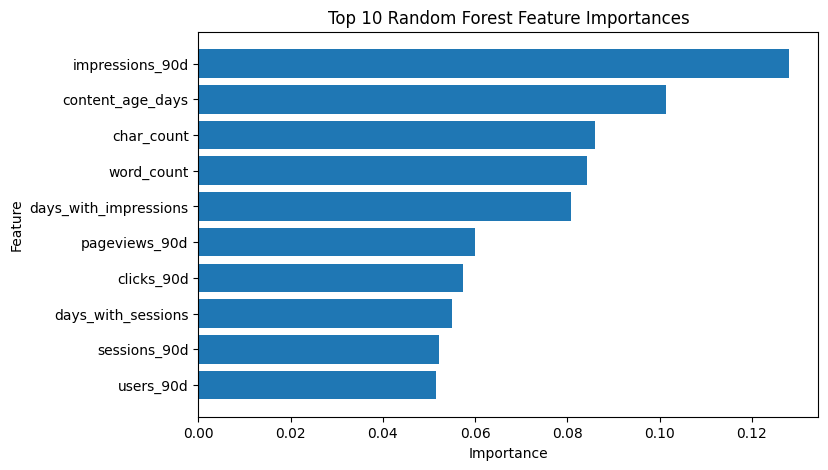

In [71]:
import matplotlib.pyplot as plt

top_features = feature_importance.head(10).sort_values(
    "importance"
)

plt.figure(figsize=(8, 5))

plt.barh(
    top_features["feature"],
    top_features["importance"]
)

plt.xlabel("Importance")
plt.ylabel("Feature")
plt.title("Top 10 Random Forest Feature Importances")

plt.show()

In [72]:
error_summary = (
    error_df[error_df["error_type"] != "correct"]
    .groupby("error_type")[
        [
            "impressions_90d",
            "content_age_days",
            "days_since_last_update",
            "word_count",
            "char_count",
            "clicks_90d",
            "sessions_90d"
        ]
    ]
    .median()
)

error_summary

,impressions_90d,content_age_days,days_since_last_update,word_count,char_count,clicks_90d,sessions_90d
error_type,,,,,,,
false_negative,1068.0,328.0,22.0,2860.0,19198.0,1.0,12.0
false_positive,957.0,223.0,20.0,2930.0,19472.0,2.0,7.5


In [73]:
from sklearn.metrics import confusion_matrix

cm = confusion_matrix(y_test, y_pred)

print("Confusion Matrix:")
print(cm)

tn, fp, fn, tp = cm.ravel()

print("\nTrue Negatives :", tn)
print("False Positives:", fp)
print("False Negatives:", fn)
print("True Positives :", tp)

Confusion Matrix:
[[1206 1094]
 [ 781 2472]]

True Negatives : 1206
False Positives: 1094
False Negatives: 781
True Positives : 2472


In [74]:
print("Test rows:", len(X_test))
print("Actual labels:", len(y_test))
print("Model predictions:", len(y_pred))
print("Baseline predictions:", len(baseline_pred))

print("\nAll lengths equal:",
      len(X_test) == len(y_test) == len(y_pred) == len(baseline_pred))

Test rows: 5553
Actual labels: 5553
Model predictions: 5553
Baseline predictions: 5553

All lengths equal: True


## Self-check

Before you submit, confirm each line honestly:

- ✅ Every section above is filled — markdown thinking AND the code that backs it
- ✅ The notebook runs top to bottom with no errors (Runtime → Run all)
- ✅ No client names, URLs, or private queries anywhere
- ✅ My claims use careful words: observed, measured, directional, decision-support
- ✅ Committed to my repo under `work/notebooks/` — then submit your repo URL on the card. Done.